# 08 — EDA Block 4: Firearm Crimes

**PACE Phase**: Analyze
**Objective**: analyze the distribution and trend of crimes committed
with a firearm, and the demographic profile of the victims involved.

**Input**: `data/processed/crimes_features.parquet`

**Research questions addressed**:
- Q4.1 — Distribution and trend of firearm crimes by LAPD area
- Q4.2 — Demographic profile of victims in firearm crimes

In [1]:
import pandas as pd             # Import the Pandas framework for DataFrame manipulation
import seaborn as sns           # Import Seaborn for statistical visualizations
import matplotlib.pyplot as plt # Import Matplotlib for plotting

pd.set_option('display.max_rows', None)         # Pandas setting to show all rows with inspection commands
pd.set_option('display.max_columns', None)      # Pandas setting to show all columns with inspection commands
pd.set_option('display.max_info_columns', 200)  # Pandas setting to show info for 200 columns with the '.info()' command

df = pd.read_parquet('../../data/processed/crimes_features.parquet') # Create the variable 'df' containing the
                                                                      # enriched dataset produced by 04_feature_engineering.ipynb
df.head() # Display the first 5 rows to recall the DataFrame's columns

,DR_NO,Date Rptd,DATE OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,hour_occ,year,month,day_of_week,hour_bins,age_group,crime_category,report_delay,is_domestic
0,1307355,2010-02-20,2010-02-20,13,Newton,1385,2,900,VIOLATION OF COURT ORDER,0913 1814 2000,48.0,M,H,501.0,SINGLE FAMILY DWELLING,0.0,No Weapon,AA,Adult Arrest,900.0,300 E GAGE AV,33.9825,-118.2695,13,2010,2,Saturday,Afternoon,Adult,person,0,False
1,11401303,2010-09-13,2010-09-12,14,Pacific,1485,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329,NaN,M,W,101.0,STREET,0.0,No Weapon,IC,Invest Cont,740.0,SEPULVEDA BL,33.9599,-118.3962,0,2010,9,Sunday,Night,NaN,property,1,False
2,70309629,2010-08-09,2010-08-09,13,Newton,1324,2,946,OTHER MISCELLANEOUS CRIME,0344,NaN,M,H,103.0,ALLEY,0.0,No Weapon,IC,Invest Cont,946.0,1300 E 21ST ST,34.0224,-118.2524,15,2010,8,Monday,Afternoon,NaN,other,0,False
3,90631215,2010-01-05,2010-01-05,6,Hollywood,646,2,900,VIOLATION OF COURT ORDER,1100 0400 1402,47.0,F,W,101.0,STREET,102.0,HAND GUN,IC,Invest Cont,900.0,CAHUENGA BL,34.1016,-118.3295,1,2010,1,Tuesday,Night,Adult,person,0,False
4,100100501,2010-01-03,2010-01-02,1,Central,176,1,122,"RAPE, ATTEMPTED",0400,47.0,F,H,103.0,ALLEY,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,122.0,8TH ST,34.0387,-118.2488,21,2010,1,Saturday,Late Night,Adult,person,1,False


## 2. Q4.1 — Distribution and trend of firearm crimes

Crimes committed with a firearm are analyzed using the `Weapon Desc` column.
The overall volume, the distribution by LAPD area, and the year-over-year trend are identified.

**Note**: crimes with no weapon are coded as "No Weapon" (a value
assigned during cleaning to records with a null `Weapon Desc`).
They are excluded from the filter to focus on firearm crimes.

In [2]:
q41_df = df[['AREA NAME','Weapon Desc','year']].copy() # Keep only the columns needed for the Q4.1 analyses
print(q41_df.head(10))

   AREA NAME                                     Weapon Desc  year
0     Newton                                       No Weapon  2010
1    Pacific                                       No Weapon  2010
2     Newton                                       No Weapon  2010
3  Hollywood                                        HAND GUN  2010
4    Central  STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)  2010
5    Central                                       No Weapon  2010
6    Central                                       No Weapon  2010
7    Central                     UNKNOWN WEAPON/OTHER WEAPON  2010
8    Central  STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)  2010
9    Central                                       No Weapon  2010


In [3]:
q41_df['Weapon Desc'].unique() # Display all distinct weapon descriptions, reviewed manually to build the 'firearm_list' below

array(['No Weapon', 'HAND GUN',
       'STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)',
       'UNKNOWN WEAPON/OTHER WEAPON', 'VERBAL THREAT', 'SIMULATED GUN',
       'FOLDING KNIFE', 'OTHER KNIFE', 'MACE/PEPPER SPRAY', 'STICK',
       'UNKNOWN FIREARM', 'SWITCH BLADE',
       'KNIFE WITH BLADE 6INCHES OR LESS', 'BOARD', 'BLUNT INSTRUMENT',
       'SEMI-AUTOMATIC PISTOL', 'VEHICLE', 'OTHER CUTTING INSTRUMENT',
       'SCISSORS', 'BOTTLE', 'KNIFE WITH BLADE OVER 6 INCHES IN LENGTH',
       'BELT FLAILING INSTRUMENT/CHAIN',
       'AUTOMATIC WEAPON/SUB-MACHINE GUN', 'CLUB/BAT', 'BRASS KNUCKLES',
       'KITCHEN KNIFE', 'AIR PISTOL/REVOLVER/RIFLE/BB GUN', 'SCREWDRIVER',
       'FIRE', 'STUN GUN', 'RIFLE', 'RAZOR BLADE', 'DIRK/DAGGER',
       'CAUSTIC CHEMICAL/POISON', 'SHOTGUN', 'ICE PICK', 'BOMB THREAT',
       'ROCK/THROWN OBJECT', 'REVOLVER', 'OTHER FIREARM', 'DEMAND NOTE',
       'BOWIE KNIFE', 'HECKLER & KOCH 93 SEMIAUTOMATIC ASSAULT RIFLE',
       'SCALDING LIQUID', 'ROPE/LIGATURE'

In [4]:
firearm_list = [
    'HAND GUN',
    'UNKNOWN FIREARM',
    'SEMI-AUTOMATIC PISTOL',
    'AUTOMATIC WEAPON/SUB-MACHINE GUN',
    'RIFLE',
    'SHOTGUN',
    'REVOLVER',
    'OTHER FIREARM',
    'HECKLER & KOCH 93 SEMIAUTOMATIC ASSAULT RIFLE',
    'UZI SEMIAUTOMATIC ASSAULT RIFLE',
    'SAWED OFF RIFLE/SHOTGUN',
    'HECKLER & KOCH 91 SEMIAUTOMATIC ASSAULT RIFLE',
    'ASSAULT WEAPON/UZI/AK47/ETC',
    'SEMI-AUTOMATIC RIFLE',
    'STARTER PISTOL/REVOLVER',
    'UNK TYPE SEMIAUTOMATIC ASSAULT RIFLE',
    'MAC-10 SEMIAUTOMATIC ASSAULT WEAPON',
    'RELIC FIREARM',
    'MAC-11 SEMIAUTOMATIC ASSAULT WEAPON',
    'ANTIQUE FIREARM',
    'M-14 SEMIAUTOMATIC ASSAULT RIFLE',
    'M1-1 SEMIAUTOMATIC ASSAULT RIFLE',
    'SIMULATED GUN',
    'AIR PISTOL/REVOLVER/RIFLE/BB GUN',
    'TOY GUN'
] # List of 'Weapon Desc' values classified as firearms, including simulated/toy/air weapons that still
  # threaten the victim with the perception of an armed attack

q41_df_filtered = q41_df[q41_df['Weapon Desc'].isin(firearm_list)].copy() # Keep only firearm-related crimes
print(q41_df_filtered.head(10))

     AREA NAME            Weapon Desc  year
3    Hollywood               HAND GUN  2010
55     Central          SIMULATED GUN  2010
94     Central               HAND GUN  2010
103    Central               HAND GUN  2010
112    Central        UNKNOWN FIREARM  2010
187    Central        UNKNOWN FIREARM  2010
240    Central  SEMI-AUTOMATIC PISTOL  2010
264    Central          SIMULATED GUN  2010
288    Central               HAND GUN  2010
293    Central               HAND GUN  2010


In [5]:
q41_df_area_volume = (
    q41_df_filtered
    .groupby(['AREA NAME'], as_index=False)
    .agg(count = ('AREA NAME','count')) # Count firearm crimes per LAPD area
).copy()

q41_df_area_volume.sort_values(by='count', ascending = False, inplace=True)

print(q41_df_area_volume.shape)
print('==========')
print(q41_df_area_volume.head(10))

(21, 2)
      AREA NAME  count
0   77th Street  17036
14    Southeast  12222
9        Newton   9879
15    Southwest   8938
5    Hollenbeck   6223
4        Harbor   5640
13      Rampart   5131
7       Mission   4254
11      Olympic   4157
10    Northeast   3933


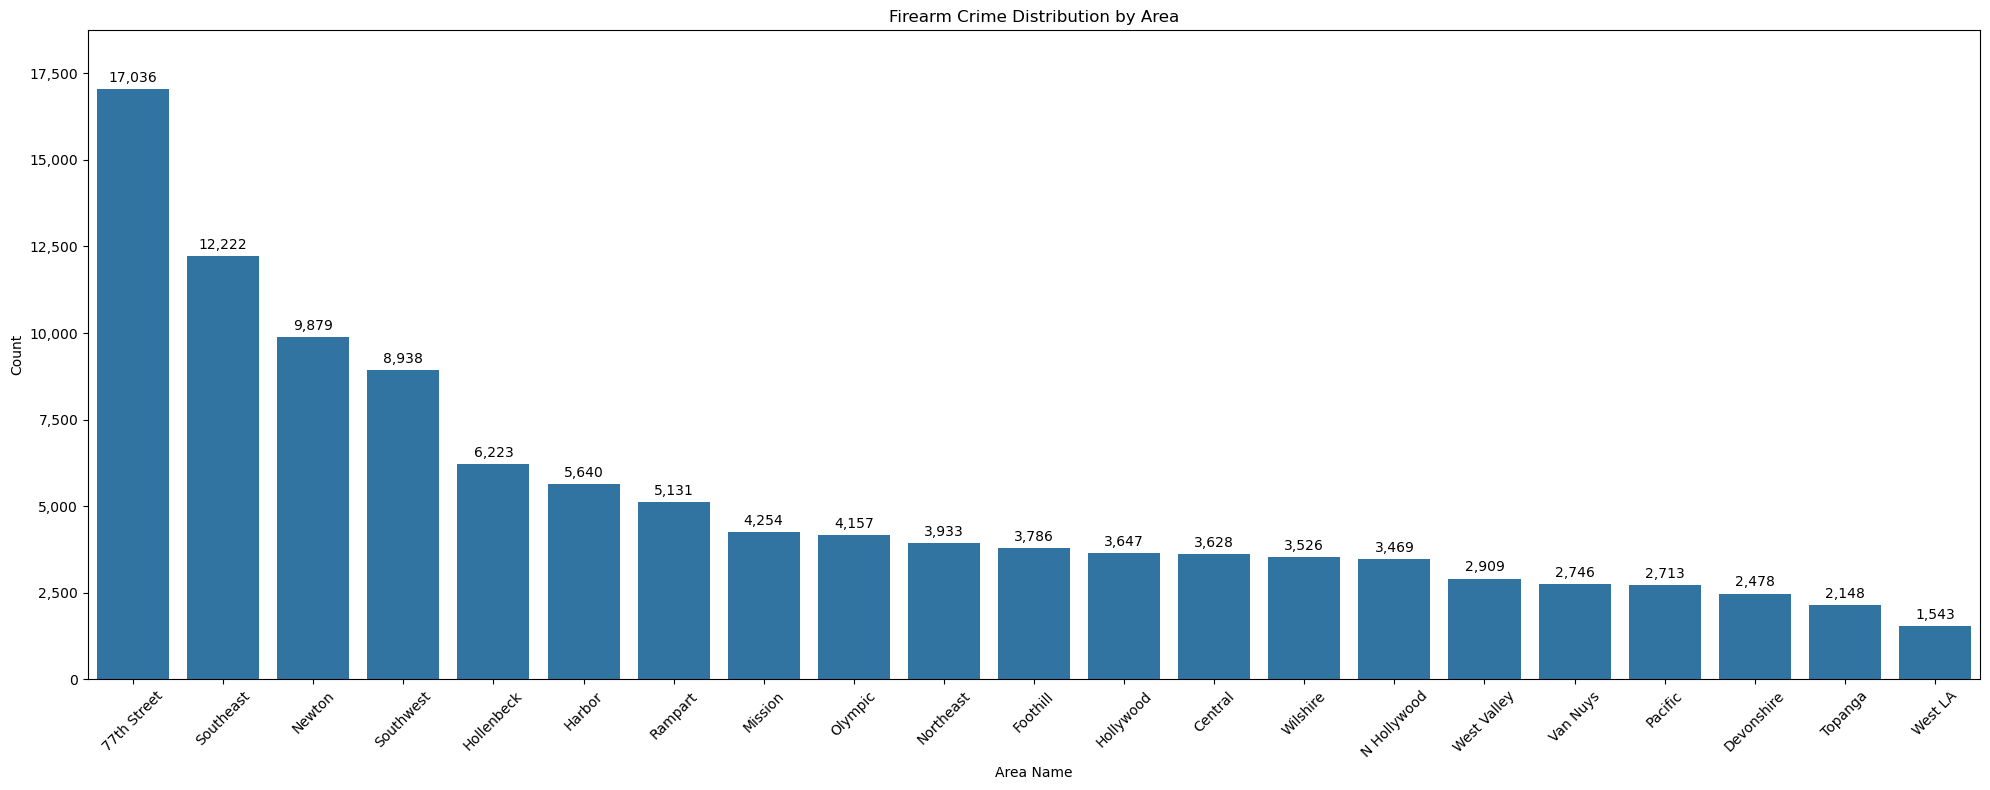

In [19]:
fig, ax = plt.subplots(figsize=(20, 8)) # Create the figure

sns.barplot(
    data=q41_df_area_volume,
    x='AREA NAME',
    y='count',
    ax=ax
)

ax.set_title('Firearm Crime Distribution by Area')
ax.set_xlabel('Area Name')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}')) # Format y-axis ticks with thousands separators
ax.bar_label(ax.containers[0], labels=[f'{v:,}' for v in q41_df_area_volume['count']], padding=3, fontsize=10) # Add value labels on top of each bar
ax.margins(y=0.1) # Extra headroom so labels don't clip at the top

plt.tight_layout()
plt.savefig('../../outputs/08_eda_block4/23_barplot_firearm_crimes_by_area.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

### Observations Q4.1 — Distribution of firearm crimes by LAPD area

**Methodological note**: the analysis includes 25 weapon categories. Three of them
are not actual firearms but are included because they are used to make
the victim perceive an armed threat:
- **SIMULATED GUN**: simulated gun
- **AIR PISTOL/REVOLVER/RIFLE/BB GUN**: air-powered weapon
- **TOY GUN**: toy gun

**Areas with the highest volume of firearm crimes**:
- 77th Street: 17,036 (dominant figure, clear gap from the rest)
- Southeast: 12,222
- Newton: 9,879
- Southwest: 8,938

**Areas with the lowest volume**:
- West LA: 1,543
- Topanga: 2,148
- Devonshire: 2,478
- Pacific: 2,713

**Geographic pattern**: all four areas with the highest number of firearm crimes (77th Street, Southeast, Newton, Southwest) fall within the top five areas for domestic crimes, though in a slightly different order: 77th Street and Southeast hold the same rank in both distributions (1st and 2nd), while Newton (5th for domestic crimes) rises to 3rd for firearm crimes, and Southwest (3rd for domestic crimes) drops to 4th for firearm crimes. This suggests an overlap between the areas with the highest incidence of armed and domestic violence, based on a comparison of rankings. A statistical deep dive could be carried out using Spearman correlation.



In [7]:
q41_df_weapon_volume = (
    q41_df_filtered
    .groupby(['Weapon Desc'], as_index = False)
    .agg(count = ('Weapon Desc', 'count')) # Count firearm crimes per specific weapon type
    .sort_values(by='count', ascending = False)
).copy()

print(q41_df_weapon_volume.head(50))

                                      Weapon Desc  count
4                                        HAND GUN  53523
16                          SEMI-AUTOMATIC PISTOL  19917
23                                UNKNOWN FIREARM  14302
13                                       REVOLVER   6632
19                                  SIMULATED GUN   4744
0                AIR PISTOL/REVOLVER/RIFLE/BB GUN   4451
11                                  OTHER FIREARM   1826
18                                        SHOTGUN   1490
14                                          RIFLE   1343
21                                        TOY GUN    461
6   HECKLER & KOCH 93 SEMIAUTOMATIC ASSAULT RIFLE    245
2                     ASSAULT WEAPON/UZI/AK47/ETC    244
3                AUTOMATIC WEAPON/SUB-MACHINE GUN    193
15                        SAWED OFF RIFLE/SHOTGUN    179
17                           SEMI-AUTOMATIC RIFLE    148
20                        STARTER PISTOL/REVOLVER    147
22           UNK TYPE SEMIAUTOM

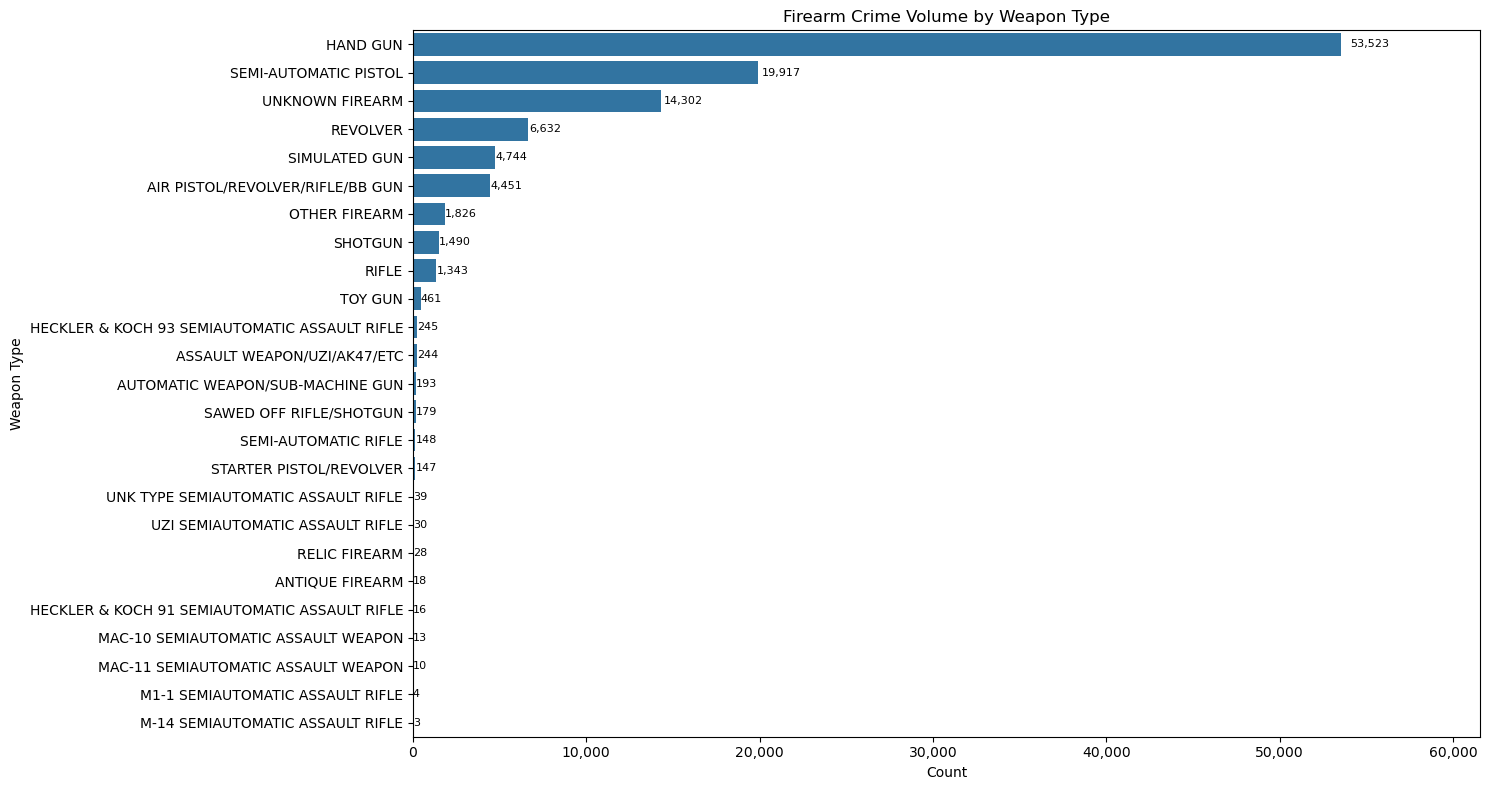

In [8]:
fig, ax = plt.subplots(figsize=(15, 8)) # Create the figure

bars = sns.barplot(
    data=q41_df_weapon_volume,
    y='Weapon Desc',
    x='count',
    ax=ax
)

for bar, value in zip(ax.patches, q41_df_weapon_volume['count']): # Add a value label at the end of each bar
    ax.text(
        bar.get_width() + bar.get_width() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{int(value):,}',
        va='center', ha='left',
        fontsize=8
    )

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}')) # Format x-axis ticks with thousands separators
ax.margins(x=0.15)

ax.set_title('Firearm Crime Volume by Weapon Type')
ax.set_xlabel('Count')
ax.set_ylabel('Weapon Type')

plt.tight_layout()
plt.savefig('../../outputs/08_eda_block4/24_barh_firearm_volume_by_weapon.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

### Observations Q4.1 — Volume by firearm type

**General pattern**: firearm crimes are heavily concentrated in a small number of weapon types — the top 4 categories alone account for approximately 81% of all recorded cases. The remaining categories are individually marginal.

**Top 4 most used weapons** (approximately ~ 85% of the total):

- **Hand Gun**: 53,523 (~ 48%) — the dominant weapon by a wide margin
- **Semi-Automatic Pistol**: 19,917 (~ 18%)
- **Unknown Firearm**: 14,302 (~ 13%)
- **Revolver**: 6,632 (~ 6%)

**Non-actual-firearm categories**: Simulated Gun (4,744) and Air Pistol/BB Gun (4,451) account for nearly 10,000 combined cases, confirming that the perceived threat is often sufficient to commit a crime without a real weapon.

**Assault weapons**: all assault rifle and automatic weapon categories (Heckler & Koch, UZI, MAC-10, MAC-11, AK47, M-14, M1-1) show negligible individual values. Their presence in the dataset, while marginal, remains a relevant data point for public safety

In [9]:
q41_df_filtered.head(10) # Display the first 10 rows to recall the filtered DataFrame's columns

,AREA NAME,Weapon Desc,year
3,Hollywood,HAND GUN,2010
55,Central,SIMULATED GUN,2010
94,Central,HAND GUN,2010
103,Central,HAND GUN,2010
112,Central,UNKNOWN FIREARM,2010
187,Central,UNKNOWN FIREARM,2010
240,Central,SEMI-AUTOMATIC PISTOL,2010
264,Central,SIMULATED GUN,2010
288,Central,HAND GUN,2010
293,Central,HAND GUN,2010


In [10]:
q41_df_trendYoY = (
    q41_df_filtered
    .groupby(['Weapon Desc', 'year'], as_index=False)
    .agg(count=('Weapon Desc', 'count')) # Count firearm crimes per weapon type and year
)

print(q41_df_trendYoY.head(50))

                         Weapon Desc  year  count
0   AIR PISTOL/REVOLVER/RIFLE/BB GUN  2010    228
1   AIR PISTOL/REVOLVER/RIFLE/BB GUN  2011    178
2   AIR PISTOL/REVOLVER/RIFLE/BB GUN  2012    160
3   AIR PISTOL/REVOLVER/RIFLE/BB GUN  2013    156
4   AIR PISTOL/REVOLVER/RIFLE/BB GUN  2014    179
5   AIR PISTOL/REVOLVER/RIFLE/BB GUN  2015    158
6   AIR PISTOL/REVOLVER/RIFLE/BB GUN  2016    317
7   AIR PISTOL/REVOLVER/RIFLE/BB GUN  2017    489
8   AIR PISTOL/REVOLVER/RIFLE/BB GUN  2018    362
9   AIR PISTOL/REVOLVER/RIFLE/BB GUN  2019    362
10  AIR PISTOL/REVOLVER/RIFLE/BB GUN  2020    429
11  AIR PISTOL/REVOLVER/RIFLE/BB GUN  2021    428
12  AIR PISTOL/REVOLVER/RIFLE/BB GUN  2022    475
13  AIR PISTOL/REVOLVER/RIFLE/BB GUN  2023    401
14  AIR PISTOL/REVOLVER/RIFLE/BB GUN  2024    129
15                   ANTIQUE FIREARM  2012      1
16                   ANTIQUE FIREARM  2014      3
17                   ANTIQUE FIREARM  2016      2
18                   ANTIQUE FIREARM  2017      1


In [11]:
real_weapon = ['HAND GUN', 'SEMI-AUTOMATIC PISTOL', 'UNKNOWN FIREARM', 'REVOLVER', 'OTHER FIREARM', 'SHOTGUN', 'RIFLE'] # Actual firearms
fake_weapon = ['SIMULATED GUN', 'AIR PISTOL/REVOLVER/RIFLE/BB GUN', 'TOY GUN'] # Weapons that only simulate a firearm threat

q41_df_trend_realWeapon = q41_df_trendYoY[q41_df_trendYoY['Weapon Desc'].isin(real_weapon)] # Keep only real firearms
q41_df_trend_fakeWeapon = q41_df_trendYoY[q41_df_trendYoY['Weapon Desc'].isin(fake_weapon)] # Keep only simulated/toy weapons

print('Unique values, real weapon trend:')
print(q41_df_trend_realWeapon['Weapon Desc'].unique())
print('=====')
print('Unique values, fake weapon trend:')
print(q41_df_trend_fakeWeapon['Weapon Desc'].unique())

Unique values, real weapon trend:
['HAND GUN' 'OTHER FIREARM' 'REVOLVER' 'RIFLE' 'SEMI-AUTOMATIC PISTOL'
 'SHOTGUN' 'UNKNOWN FIREARM']
=====
Unique values, fake weapon trend:
['AIR PISTOL/REVOLVER/RIFLE/BB GUN' 'SIMULATED GUN' 'TOY GUN']


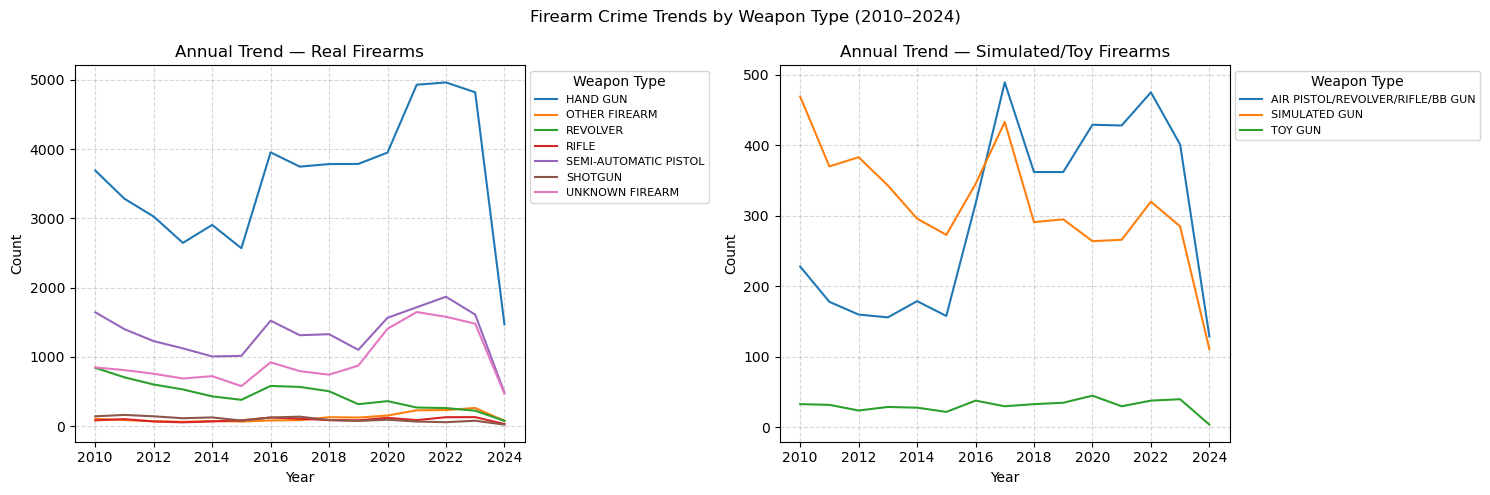

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5)) # Two side-by-side subplots: real weapons vs simulated/toy weapons

sns.lineplot(
    data=q41_df_trend_realWeapon,
    x='year',
    y='count',
    hue='Weapon Desc', # One line per real weapon type
    ax=ax1
)

sns.lineplot(
    data=q41_df_trend_fakeWeapon,
    x='year',
    y='count',
    hue='Weapon Desc', # One line per simulated/toy weapon type
    ax=ax2
)

ax1.set_title('Annual Trend — Real Firearms')
ax2.set_title('Annual Trend — Simulated/Toy Firearms')

for ax in [ax1, ax2]:
    ax.set_xlabel('Year')
    ax.set_ylabel('Count')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title='Weapon Type', loc='upper left', bbox_to_anchor=(1, 1), fontsize=8) # Legend placed outside the plot area

plt.suptitle('Firearm Crime Trends by Weapon Type (2010–2024)')
plt.tight_layout()
plt.savefig('../../outputs/08_eda_block4/25_lineplot_firearm_trends.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

### Observations Q4.1 — Yearly trend of firearm crimes

**Real weapons — general pattern**: a downward trend for all categories until 2015, followed by a reversal and progressive rebound. The 2015 decline is consistent with the anomalous behavior documented in the introductory methodological note.

**Hand Gun**: the dominant line, with a clear acceleration from 2020 and
a peak in 2022-2023 (~5,000 cases).

**Semi-Automatic Pistol**: progressive growth from 2015, moving
against the trend for Revolver.

**Unknown Firearm**: **Unknown Firearm**: fluctuates between ~ 600 and ~ 900 cases, remaining stable until 2017 when it shows a sharp increase. Its persistent presence reflects cases where the weapon type could not be determined at the time of reporting.

**Revolver**: the only category with a nearly uninterrupted negative trend
from 2010 to 2024.

**Rifle, Shotgun, Other Firearm**: stable at low values throughout
the period.

**Simulated weapons**:
- **Air Pistol/BB Gun**: peak in 2017 (~490 cases), then
  stabilizing at higher values than the pre-2016 period.
- **Simulated Gun**: declining trend since 2010.
- **Toy Gun**: stable at low values throughout the period.

**2024**: a drop across all categories, consistent with the
already documented incomplete data.

## 3. Q4.2 — Demographic profile of victims in firearm crimes

The demographic profile (sex, age, descent) of victims in crimes committed with a firearm is analyzed, using the same `firearm_list` filter
from Q4.1.

In [13]:
q42_df = df.loc[
df['Weapon Desc'].isin(firearm_list), # Reuse the firearm list from Q4.1
['Vict Sex','Vict Descent','age_group']].copy()

print(q42_df.head(15))

    Vict Sex Vict Descent    age_group
3          F            W        Adult
55         M            H  Young Adult
94         F            B  Young Adult
103        M            O        Adult
112        M            B        Adult
187        M            H        Adult
240        M            W  Young Adult
264        F            W        Adult
288        F            O        Adult
293        M            B  Young Adult
294        M            B  Young Adult
307        M            H        Adult
311        M            H        Adult
372        F            W        Adult
396        M            H  Young Adult


In [14]:
sex_labels = {'F': 'Female', 'M': 'Male', 'X': 'Unknown'}
descent_labels = {
    'A': 'Other Asian', 'B': 'Black', 'C': 'Chinese', 'D': 'Cambodian',
    'F': 'Filipino', 'G': 'Guamanian', 'H': 'Hispanic/Latin/Mexican',
    'I': 'American Indian', 'J': 'Japanese', 'K': 'Korean', 'L': 'Laotian',
    'O': 'Other', 'P': 'Pacific Islander', 'S': 'Samoan', 'U': 'Hawaiian',
    'V': 'Vietnamese', 'W': 'White', 'X': 'Unknown', 'Z': 'Asian Indian',
    '-': 'Unknown'
} # Descent code labels, from the LAPD Crime Data Dictionary (data.lacity.org)

q42_df['Vict Sex'] = q42_df['Vict Sex'].map(sex_labels)         # Map each sex code to its readable label
q42_df['Vict Descent'] = q42_df['Vict Descent'].map(descent_labels) # Map each descent code to its readable label

print(q42_df.head(15))

    Vict Sex            Vict Descent    age_group
3     Female                   White        Adult
55      Male  Hispanic/Latin/Mexican  Young Adult
94    Female                   Black  Young Adult
103     Male                   Other        Adult
112     Male                   Black        Adult
187     Male  Hispanic/Latin/Mexican        Adult
240     Male                   White  Young Adult
264   Female                   White        Adult
288   Female                   Other        Adult
293     Male                   Black  Young Adult
294     Male                   Black  Young Adult
307     Male  Hispanic/Latin/Mexican        Adult
311     Male  Hispanic/Latin/Mexican        Adult
372   Female                   White        Adult
396     Male  Hispanic/Latin/Mexican  Young Adult


In [15]:
q42_df_sex = (
    q42_df
    .groupby(['Vict Sex'], as_index = False)
    .agg(count = ('Vict Sex', 'count')) # Count firearm crime victims per sex
)

q42_df_age = (
    q42_df
    .groupby(['age_group'], as_index = False, observed = True)
    .agg(count = ('age_group', 'count')) # Count firearm crime victims per age bracket
)

q42_df_descent = (
    q42_df
    .groupby(['Vict Descent'], as_index = False)
    .agg(count = ('Vict Descent', 'count')) # Count firearm crime victims per descent
    .sort_values('count', ascending = False)
)

print('Vict Sex DataFrame')
print(q42_df_sex)
print('=====')
print('Vict Age DataFrame')
print(q42_df_age)
print('=====')
print('Vict Descent DataFrame')
print(q42_df_descent)

Vict Sex DataFrame
  Vict Sex  count
0   Female  26191
1     Male  77308
2  Unknown   6507
=====
Vict Age DataFrame
     age_group  count
0        Child   1376
1   Adolescent   5900
2  Young Adult  50137
3        Adult  35924
4       Senior   2532
=====
Vict Descent DataFrame
              Vict Descent  count
6   Hispanic/Latin/Mexican  51770
1                    Black  29611
16                   White  11454
14                 Unknown   8287
10                   Other   7195
11             Other Asian   1399
8                   Korean    175
3                 Filipino     50
0          American Indian     26
2                  Chinese     10
5                 Hawaiian      7
4                Guamanian      6
12        Pacific Islander      6
7                 Japanese      5
13                  Samoan      3
9                  Laotian      1
15              Vietnamese      1


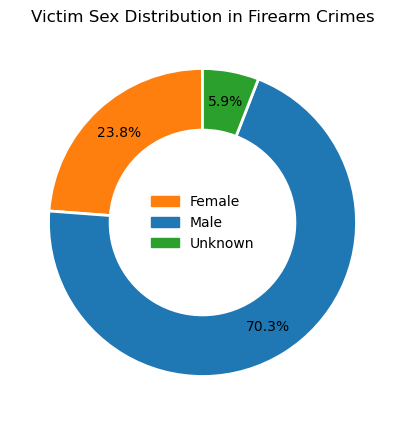

In [16]:
colors = ['#ff7f0e', '#1f77b4', '#2ca02c']

fig, ax = plt.subplots(figsize=(5, 5)) # Create the figure

wedges, texts, autotexts = ax.pie(
    x=q42_df_sex['count'],
    wedgeprops={'width': 0.4, 'linewidth': 2, 'edgecolor': 'white'}, # 'width' < 1 turns the pie into a donut
    colors=colors,
    autopct='%1.1f%%', # Show the percentage on each wedge
    startangle=90,
    pctdistance=0.8
)

labels = q42_df_sex['Vict Sex'].tolist()
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, color=colors[i], label=labels[i]) # One legend swatch per category
    for i in range(len(labels))
]

ax.legend(
    handles=legend_elements,
    loc='center', # Legend placed in the donut's hollow center
    frameon=False,
    fontsize=10
)

ax.set_title('Victim Sex Distribution in Firearm Crimes')

plt.savefig('../../outputs/08_eda_block4/26_donut_victim_sex_firearm.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

### Q4.2 — Firearm crime victim demographic profile: Sex

Firearm crimes show a clear male prevalence among
victims:

- **Male**: 77,308 (70.3%)
- **Female**: 26,191 (23.8%)
- **Unknown**: 6,507 (5.9%)

The most notable finding is the gender gap: males account for almost
three-quarters of victims. This is the opposite pattern from what was
observed in domestic crimes (Block 3), where women were 75.8%
of victims. Firearm crimes have a gender dynamic
profoundly different from domestic crimes.

**Note**: the Unknown share (5.9%) indicates cases where the victim's
sex wasn't recorded, not the victim's identity itself.

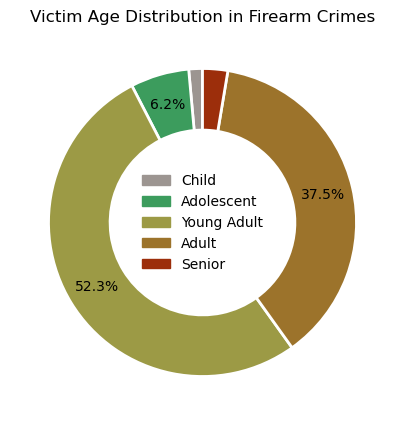

In [17]:
colors = ['#9C9591', '#3C9C5D', '#9C9A45', '#9C732B', '#9C2E0B']

fig, ax = plt.subplots(figsize=(5, 5)) # Create the figure

wedges, texts, autotexts = ax.pie(
    x=q42_df_age['count'],
    wedgeprops={'width': 0.4, 'linewidth': 2, 'edgecolor': 'white'}, # 'width' < 1 turns the pie into a donut
    colors=colors,
    autopct=lambda p: f'{p:.1f}%' if p > 5 else '', # Hide the percentage label on slivers below 5%
    startangle=90,
    pctdistance=0.8
)

labels = q42_df_age['age_group'].tolist()
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, color=colors[i], label=labels[i]) # One legend swatch per age bracket
    for i in range(len(labels))
]

ax.legend(
    handles=legend_elements,
    loc='center', # Legend placed in the donut's hollow center
    frameon=False,
    fontsize=10
)

ax.set_title('Victim Age Distribution in Firearm Crimes')

plt.savefig('../../outputs/08_eda_block4/27_donut_victim_age_firearm.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

### Q4.2 — Firearm crime victim demographic profile: Age group

- **Young Adult** (18-34): 50,137 (52.3%)
- **Adult** (35-64): 35,924 (37.5%)
- **Adolescent** (13-17): 5,900 (6.2%)
- **Senior** (65+): 2,532 (2.6%)
- **Child** (0-12): 1,376 (1.4%)

**Young Adult dominant**: the 18-34 group accounts for over half
of firearm crime victims. Compared with the previous
analyses, this share is significantly higher than in the
overall dataset (40.5%) and in domestic crimes (49.2%). Firearm
crimes disproportionately affect young adults.

**Adolescent relative increase**: for adolescents the share rises from
3.4% in the overall dataset to 6.2% in firearm crimes —
nearly double. This finding should be flagged in the final report.

**Child and Senior marginal**: both groups have very
low shares (1.4% and 2.6%), consistent with the pattern observed in
non-domestic crimes in Block 2.

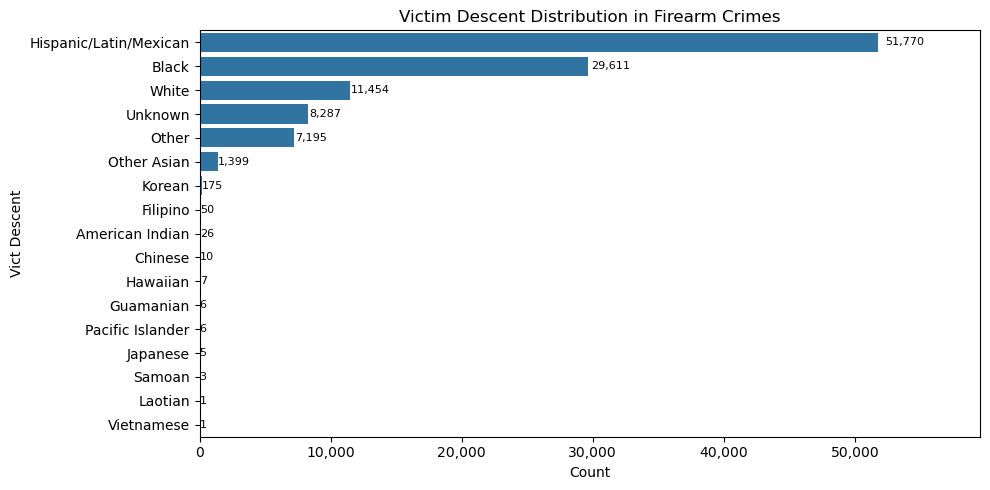

In [18]:
fig, ax = plt.subplots(figsize=(10, 5)) # Create the figure

bars = sns.barplot(
    data=q42_df_descent,
    y='Vict Descent',
    x='count',
    ax=ax
)

for bar, value in zip(ax.patches, q42_df_descent['count']): # Add a value label at the end of each bar
    ax.text(
        bar.get_width() + bar.get_width() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{int(value):,}',
        va='center', ha='left',
        fontsize=8
    )

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}')) # Format x-axis ticks with thousands separators
ax.margins(x=0.15)
ax.set_title('Victim Descent Distribution in Firearm Crimes')
ax.set_xlabel('Count')
ax.set_ylabel('Vict Descent')

plt.tight_layout()
plt.savefig('../../outputs/08_eda_block4/28_barh_victim_descent_firearm.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

### Q4.2 — Firearm crime victim demographic profile: Descent

- **Hispanic/Latin/Mexican**: 51,770 — the dominant category, confirming
  the pattern already observed in previous blocks.
- **Black**: 29,611 — second place, with a clear gap from the top category.
- **White**: 11,454 — third place, with a further gap.
- **Unknown**: 8,287
- **Other**: 7,195
- **Other Asian**: 1,399
- All other descents: negligible values.

**Comparison with the overall dataset (Block 2)**: firearm crimes
show a shift in the relative distribution compared to the
overall dataset:
- **Black** rises from an overall 15.1% to about 27% in firearm
  crimes — nearly double in relative terms.
- **White** drops from an overall 22.9% to about 10.4% in firearm
  crimes.

The relative shift between the two contexts is directly observable
from the data.

**Methodological note**: the values are absolute counts. Without
population data by ethnic group it isn't possible to assess absolute
over/underrepresentation. The internal comparison with the
overall dataset is methodologically valid because both
refer to the same base dataset.